In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
all_news = pd.read_csv('merged_news.csv')
train_news = pd.read_csv('/Users/d.mkhlnk/Downloads/test_d.csv') #обучающий набор данных

In [3]:
all_news

,Unnamed: 0,level_0,Company,Date,filtered_text,Лаг_1,Лаг_2,Лаг_3
0,0,0,Sber,2018-01-10,раскрытие акционерный общество сеть интернет с...,0.005202,-0.000042,0.004574
1,1,1,Sber,2018-01-16,отдельный решение принять наблюдательный совет...,0.000751,0.024159,0.011658
2,2,2,Sber,2018-01-19,передача получить депозитарий выплата ценный б...,0.006332,0.008011,0.020736
3,3,3,Sber,2018-02-09,передача получить депозитарий выплата ценный б...,0.019559,0.032221,0.046558
4,4,4,Sber,2018-02-12,проведение заседание наблюдательный совет эмит...,0.012662,0.026999,0.036684
...,...,...,...,...,...,...,...,...
2747,2747,2747,positive tech,2024-11-29,совершение эмитент сделка общий сведение полны...,0.025517,-0.038379,-0.048375
2748,2748,2748,positive tech,2024-12-02,совершение эмитент сделка общий сведение полны...,-0.063896,-0.073893,-0.021907
2749,2749,2749,positive tech,2024-12-04,выплатить доход выплата причитаться владелец ц...,0.051985,0.061058,0.110838
2750,2750,2750,positive tech,2024-12-10,совершение эмитент сделка общий сведение полны...,0.029233,0.006358,0.014674


In [4]:
train_news

,Id,1. Существенное,1. Направление,body_text_clust_3,filtered_text
0,S_15,1,1.0,"['оказывать', 'эмитент', 'стоимость', 'котиров...",оказывать стоимость котировка сократить резуль...
1,S_16,0,NaN,"['проведение', 'заседание', 'наблюдательный', ...",проведение заседание наблюдательный совет пове...
2,S_23,1,1.0,"['досрочный', 'погашение', 'облигация', 'эмите...",досрочный погашение облигация облигация которы...
3,S_27,0,NaN,"['досрочный', 'погашение', 'облигация', 'эмите...",досрочный погашение облигация облигация которы...
4,S_30,0,NaN,"['отдельный', 'решение', 'принять', 'наблюдате...",отдельный решение принять наблюдательный совет...
...,...,...,...,...,...
995,m_1048,1,NaN,"['раскрытие', 'эмитент', 'ежеквартальный', 'от...",раскрытие ежеквартальный отчёт вид документ ра...
996,m_1057,1,1.0,"['решение', 'совет', 'директор', 'наблюдательн...",решение совет директор наблюдательный совет за...
997,m_1064,0,NaN,"['раскрытие', 'акционерный', 'общество', 'сеть...",раскрытие акционерный общество сеть интернет с...
998,m_1076,1,-1.0,"['прекращение', 'лицо', 'право', 'распоряжатьс...",прекращение лицо право распоряжаться определён...


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer


### обучение модели


In [7]:
y = train_news['1. Существенное']
X = train_news['filtered_text']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42) 
vectorizer = TfidfVectorizer()

In [9]:
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized  = vectorizer.transform(X_test)

In [10]:
rfc = RandomForestClassifier()

In [11]:
rfc.fit(X_train_vectorized, y_train)

RandomForestClassifier()

In [12]:
preds = rfc.predict(X_test_vectorized)

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

In [14]:
print (classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       126
           1       0.88      0.58      0.70        24

    accuracy                           0.92       150
   macro avg       0.90      0.78      0.83       150
weighted avg       0.92      0.92      0.91       150



### подбор гиперпараметров 

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Модель
rf = RandomForestClassifier(random_state=42)

# Сетка параметров
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Grid Search с 5-фолдовой кросс-валидацией
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

# Подгоняем на данных
grid_search.fit(X_train_vectorized, y_train)

# Лучшие параметры
print("Лучшие параметры:", grid_search.best_params_)

# Лучшая модель
best_model = grid_search.best_estimator_

# Предсказание
preds = best_model.predict(X_test_vectorized)


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [17]:
from sklearn.utils.class_weight import compute_class_weight

# Получение весов классов
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y)

# Создание модели с взвешиванием классов

rfc_params = RandomForestClassifier(n_estimators= 100, max_depth=None, max_features= 'sqrt', min_samples_leaf=2, min_samples_split=5,class_weight=dict(enumerate(class_weights)))


In [18]:
rfc_params.fit(X_train_vectorized, y_train)

RandomForestClassifier(class_weight={0: 0.5938242280285035,
                                     1: 3.1645569620253164},
                       min_samples_leaf=2, min_samples_split=5)

In [19]:
preds_params = rfc_params.predict(X_test_vectorized)

In [20]:
print(classification_report(y_test, preds_params))


              precision    recall  f1-score   support

           0       0.92      0.97      0.95       126
           1       0.78      0.58      0.67        24

    accuracy                           0.91       150
   macro avg       0.85      0.78      0.81       150
weighted avg       0.90      0.91      0.90       150



### Предскажем сущетсвенность новостей для всей выборки

In [22]:
X_all = all_news['filtered_text']

In [23]:
all_news['prediсted'] = rfc.predict(vectorizer.transform(X_all))

In [24]:
all_news

,Unnamed: 0,level_0,Company,Date,filtered_text,Лаг_1,Лаг_2,Лаг_3,prediсted
0,0,0,Sber,2018-01-10,раскрытие акционерный общество сеть интернет с...,0.005202,-0.000042,0.004574,0
1,1,1,Sber,2018-01-16,отдельный решение принять наблюдательный совет...,0.000751,0.024159,0.011658,0
2,2,2,Sber,2018-01-19,передача получить депозитарий выплата ценный б...,0.006332,0.008011,0.020736,0
3,3,3,Sber,2018-02-09,передача получить депозитарий выплата ценный б...,0.019559,0.032221,0.046558,0
4,4,4,Sber,2018-02-12,проведение заседание наблюдательный совет эмит...,0.012662,0.026999,0.036684,0
...,...,...,...,...,...,...,...,...,...
2747,2747,2747,positive tech,2024-11-29,совершение эмитент сделка общий сведение полны...,0.025517,-0.038379,-0.048375,1
2748,2748,2748,positive tech,2024-12-02,совершение эмитент сделка общий сведение полны...,-0.063896,-0.073893,-0.021907,1
2749,2749,2749,positive tech,2024-12-04,выплатить доход выплата причитаться владелец ц...,0.051985,0.061058,0.110838,0
2750,2750,2750,positive tech,2024-12-10,совершение эмитент сделка общий сведение полны...,0.029233,0.006358,0.014674,1


In [25]:
important = all_news[all_news['prediсted']==1]

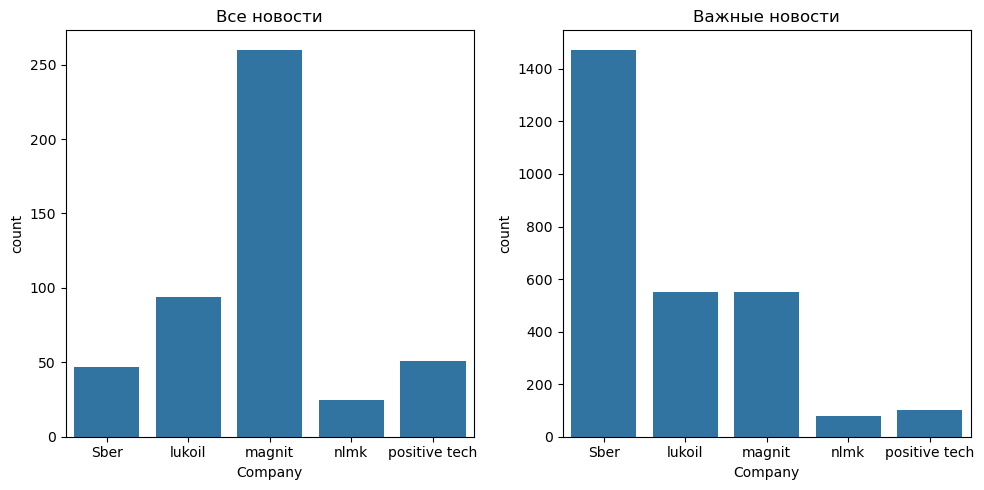

In [26]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=important, x = 'Company')
plt.title('Вcе новости')
plt.subplot(1, 2, 2)
sns.countplot(data=all_news, x = 'Company')
plt.title('Важные новости')
plt.tight_layout()

### Предскажем изменение цен только на существенных новостях 

In [28]:
from sklearn.ensemble import RandomForestRegressor


In [29]:
y_price = important['Лаг_1']
X_important = important['filtered_text']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_important, y_price, test_size=0.15, random_state=42)
vectorizer_reg = TfidfVectorizer()
X_important_train_vec = vectorizer_reg.fit_transform(X_train)
X_important_test_vec = vectorizer_reg.transform(X_test)

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Модель
rf = RandomForestRegressor(random_state=42)

# Сетка параметров
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Grid Search с 5-фолдовой кросс-валидацией
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

# Подгоняем на данных
grid_search.fit(X_important_train_vec, y_train)

# Лучшие параметры
print("Лучшие параметры:", grid_search.best_params_)

# Лучшая модель
best_model = grid_search.best_estimator_

# Предсказание
preds = best_model.predict(X_important_test_vec)


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Лучшие параметры: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}


In [32]:
rfr = RandomForestRegressor(n_estimators=300, min_samples_leaf=2, min_samples_split= 5,  max_depth=10)


In [33]:
rfr.fit(X_important_train_vec, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300)

In [34]:
preds_lag = rfr.predict(X_important_test_vec)

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
print (f'Стандартное отклонение {round(y_price.std(), 4)}')
print (f'Среднее изменение стоимости {round(y_price.mean(), 4)}')

Стандартное отклонение 0.0196
Среднее изменение стоимости -0.0002


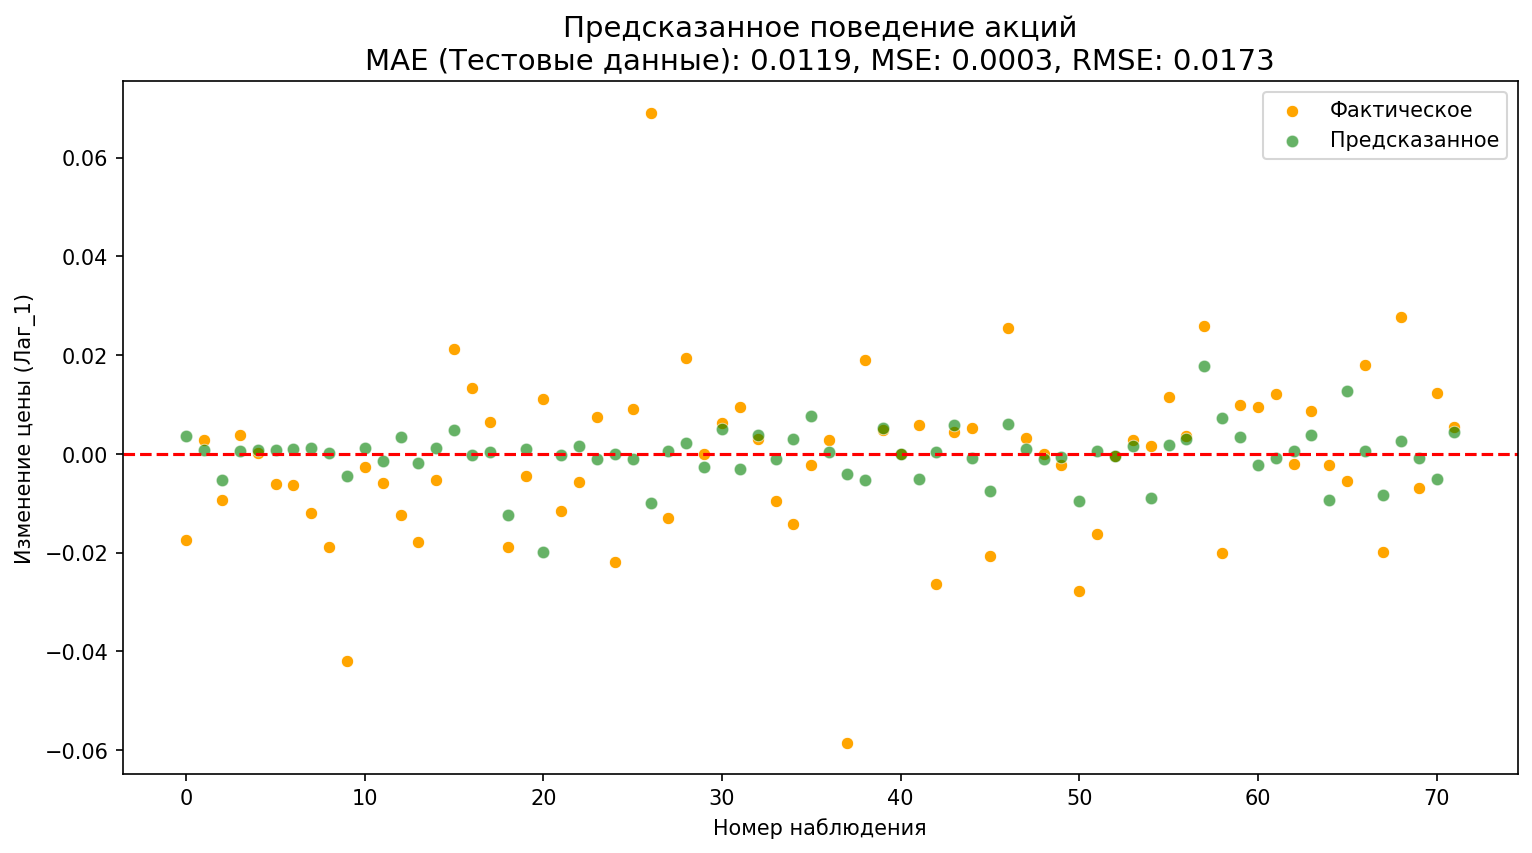

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6), dpi=150)
mae = mean_absolute_error(y_test, preds_lag)
mse = mean_squared_error(y_test, preds_lag)
# Облако точек для фактических значений
sns.scatterplot(x=range(len(y_test)), y=y_test.values, label="Фактическое", color="orange", alpha=1)

# Линия предсказанных значений
sns.scatterplot(x=range(len(y_test)), y=preds_lag, label="Предсказанное", color="green", alpha=0.6)
#plt.plot(range(len(preds)), preds, label="Предсказанное", color="blue", linewidth=2)

# Подписи осей и заголовок
plt.xlabel("Номер наблюдения")
plt.ylabel("Изменение цены (Лаг_1)")
plt.axhline(y = 0, ls = '--', c = 'r')
plt.title(f'Предсказанное поведение акций\nMAE (Тестовые данные): {mae:.4f}, MSE: {mse:.4f}, RMSE: {round(np.sqrt(mse), 4)}',fontsize=14)
# Легенда
plt.legend()

# Показываем график
plt.show()


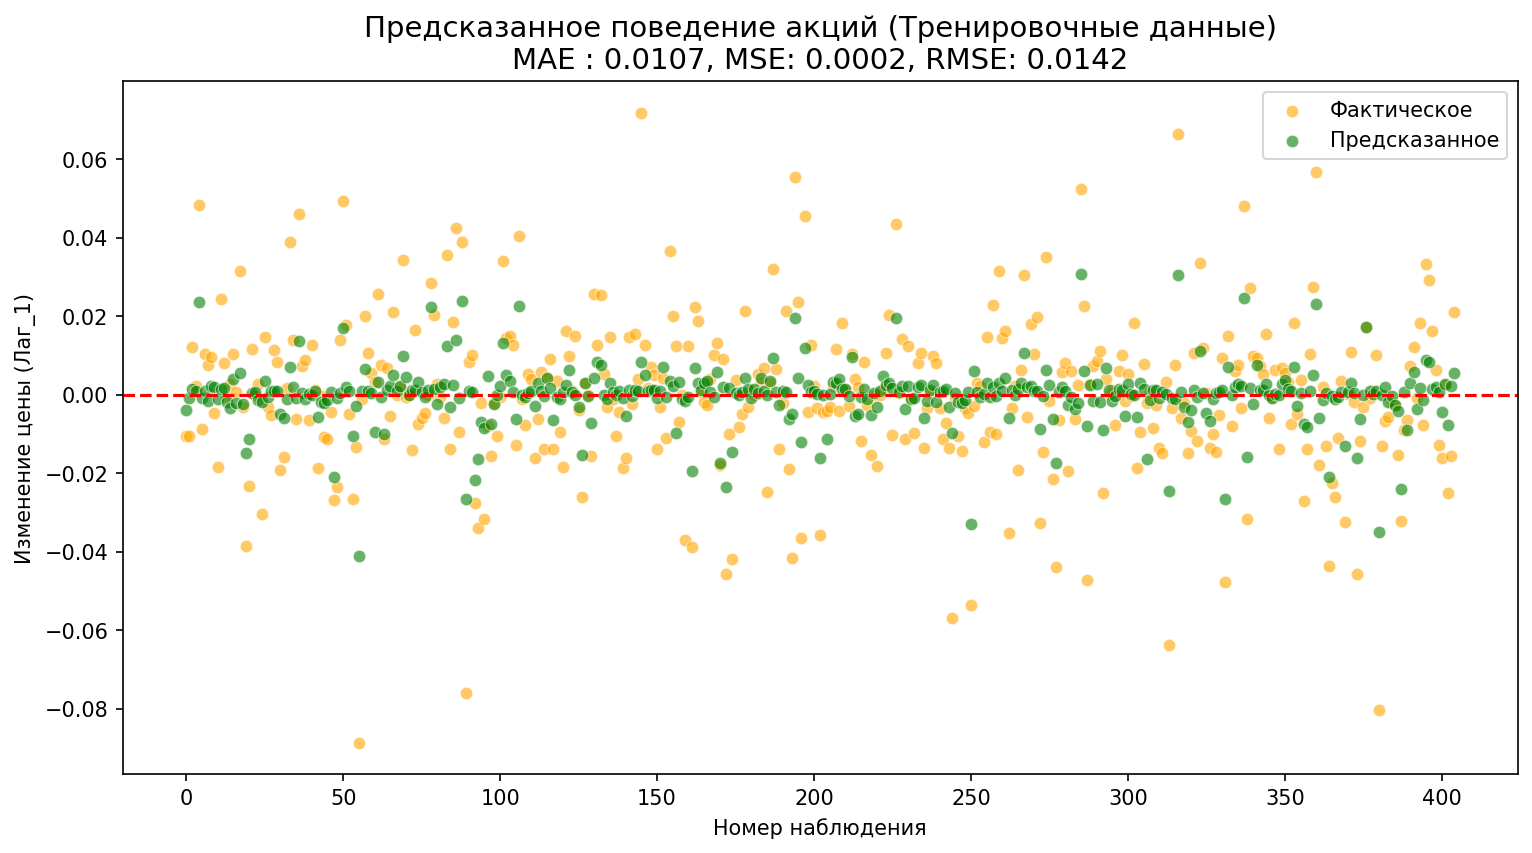

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6), dpi=150)
mae = mean_absolute_error(y_train, rfr.predict(X_important_train_vec))
mse = mean_squared_error(y_train, rfr.predict(X_important_train_vec))
# Облако точек для фактических значений
sns.scatterplot(x=range(len(y_train)), y=y_train, label="Фактическое", color="orange", alpha=0.6)

# Линия предсказанных значений
sns.scatterplot(x=range(len(y_train)), y=rfr.predict(X_important_train_vec), label="Предсказанное", color="green", alpha=0.6)
#plt.plot(range(len(preds)), preds, label="Предсказанное", color="blue", linewidth=2)
plt.axhline(y = 0, ls = '--', c = 'r')
# Подписи осей и заголовок
plt.xlabel("Номер наблюдения")
plt.ylabel("Изменение цены (Лаг_1)")

plt.title(f'Предсказанное поведение акций (Тренировочные данные)\nMAE : {mae:.4f}, MSE: {mse:.4f}, RMSE: {round(np.sqrt(mse), 4)}',fontsize=14)
# Легенда
plt.legend()

# Показываем график
plt.show()


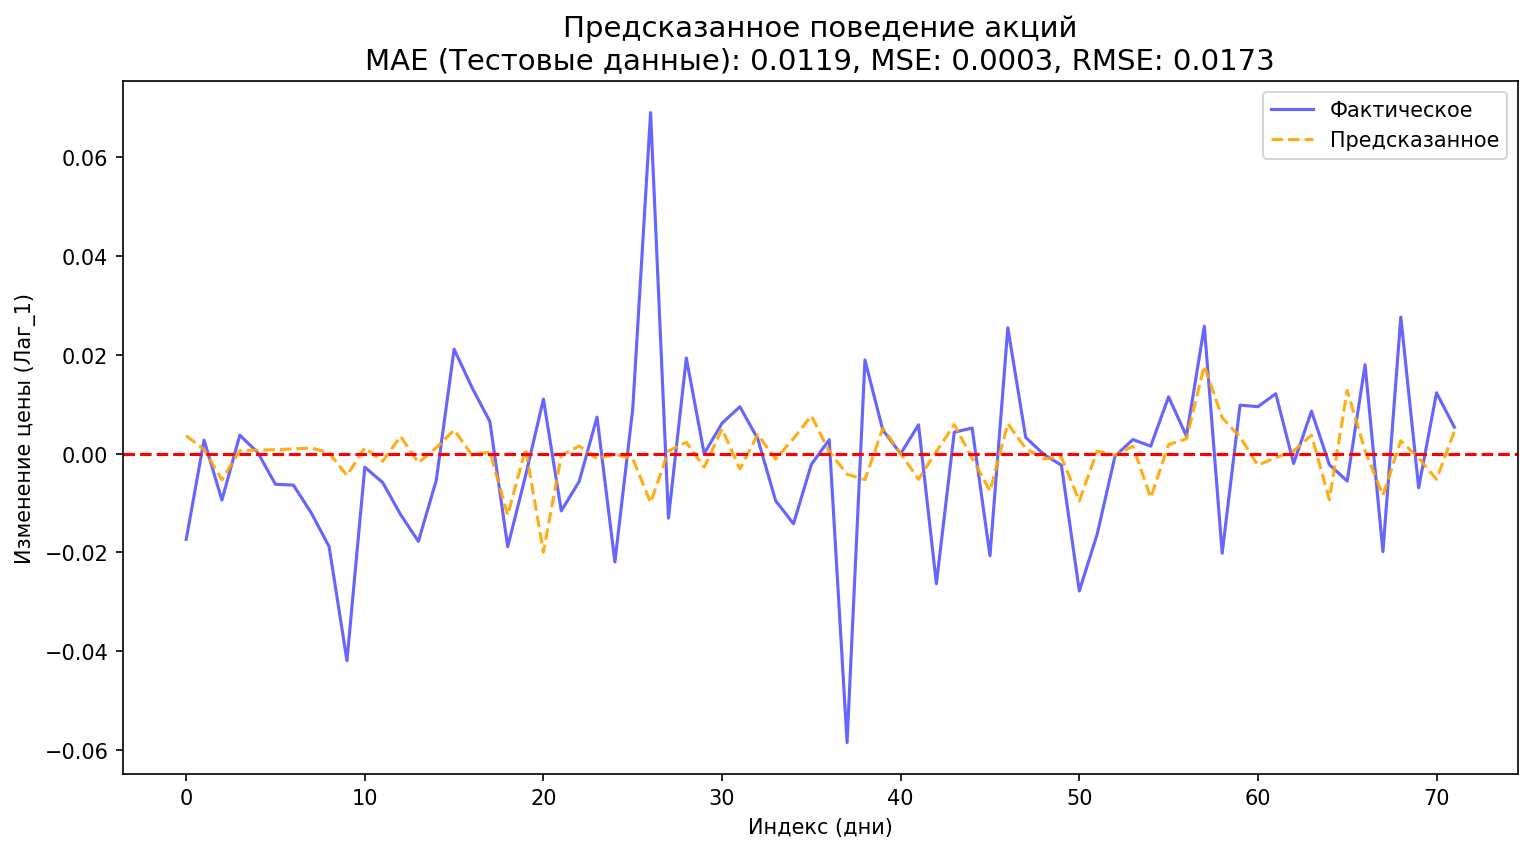

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6), dpi=150)
mae = mean_absolute_error(y_test, preds_lag)
mse = mean_squared_error(y_test, preds_lag)
# Облако точек для фактических значений
plt.plot(range(len(y_test)), y_test.values, label="Фактическое", color="blue", alpha=0.6)

# Линия предсказанных значений
plt.plot(range(len(y_test)), preds_lag, label="Предсказанное", ls = '--',  color="orange", alpha=0.9)
#plt.plot(range(len(preds)), preds, label="Предсказанное", color="blue", linewidth=2)
plt.axhline(y = 0, ls = '--', c = 'r')
# Подписи осей и заголовок
plt.xlabel("Индекс (дни)")
plt.ylabel("Изменение цены (Лаг_1)")

plt.title(f'Предсказанное поведение акций\nMAE (Тестовые данные): {mae:.4f}, MSE: {mse:.4f}, RMSE: {round(np.sqrt(mse), 4)}',fontsize=14)
# Легенда
plt.legend()

# Показываем график
plt.show()


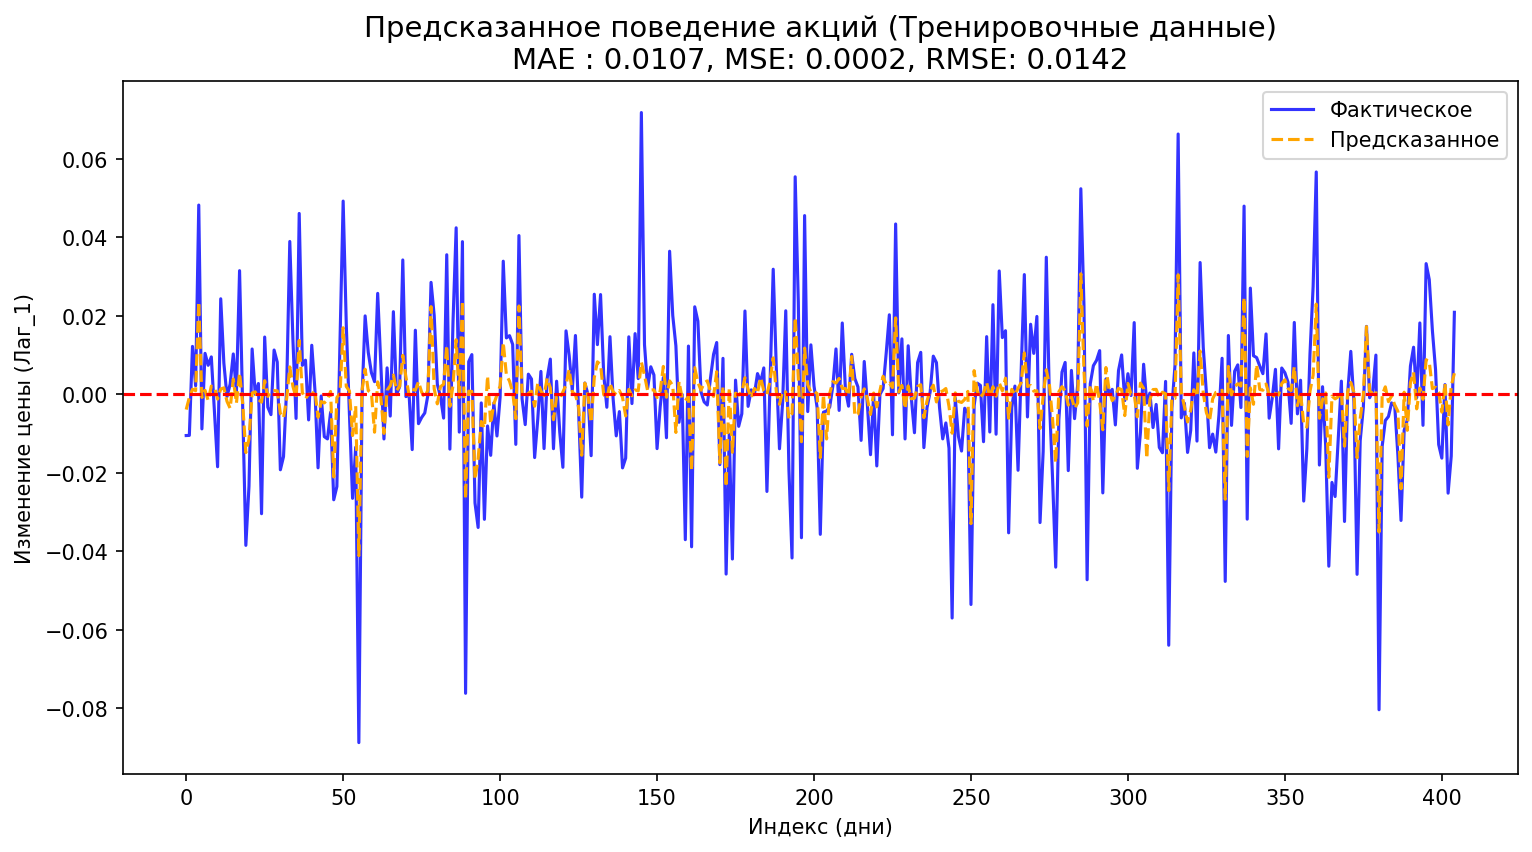

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6), dpi=150)
mae = mean_absolute_error(y_train, rfr.predict(X_important_train_vec))
mse = mean_squared_error(y_train, rfr.predict(X_important_train_vec))
# Облако точек для фактических значений
plt.plot(range(len(y_train)), y_train, label="Фактическое", color="blue", alpha=0.8)

# Линия предсказанных значений
plt.plot(range(len(y_train)), rfr.predict(X_important_train_vec), ls ='--',  label="Предсказанное", color="orange", alpha=1)
#plt.plot(range(len(preds)), preds, label="Предсказанное", color="blue", linewidth=2)

# Подписи осей и заголовок
plt.xlabel("Индекс (дни)")
plt.ylabel("Изменение цены (Лаг_1)")
plt.axhline(y = 0, ls = '--', c = 'r')
plt.title(f'Предсказанное поведение акций (Тренировочные данные)\nMAE : {mae:.4f}, MSE: {mse:.4f}, RMSE: {round(np.sqrt(mse), 4)}',fontsize=14)
# Легенда
plt.legend()

# Показываем график
plt.show()


In [40]:
important['predicted_lag1'] = rfr.predict(vectorizer_reg.transform(X_important))

/var/folders/3_/t25c274s2dd06j97r5rn8pp40000gn/T/ipykernel_72899/3194572218.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  important['predicted_lag1'] = rfr.predict(vectorizer_reg.transform(X_important))


In [41]:
important

,Unnamed: 0,level_0,Company,Date,filtered_text,Лаг_1,Лаг_2,Лаг_3,prediсted,predicted_lag1
50,50,50,Sber,2018-06-14,отдельный решение принять наблюдательный совет...,-0.021921,-0.036645,-0.038100,1,-0.000119
267,267,267,Sber,2019-07-22,выплатить доход эмиссионный ценный бумага эмит...,0.009204,0.001302,0.011009,1,0.001061
368,368,368,Sber,2019-12-16,выплатить доход эмиссионный ценный бумага эмит...,0.000621,0.019482,0.010506,1,0.001076
425,425,425,Sber,2020-03-25,выплатить доход эмиссионный ценный бумага эмит...,-0.000053,-0.041802,-0.027381,1,0.000969
473,473,473,Sber,2020-06-15,выплатить доход эмиссионный ценный бумага эмит...,0.002120,0.003947,-0.017272,1,-0.000114
...,...,...,...,...,...,...,...,...,...,...
2745,2745,2745,positive tech,2024-11-20,совершение эмитент сделка общий сведение полны...,0.005368,0.003185,-0.040585,1,0.004532
2746,2746,2746,positive tech,2024-11-22,совершение эмитент сделка общий сведение полны...,-0.043770,-0.102340,-0.075837,1,-0.021121
2747,2747,2747,positive tech,2024-11-29,совершение эмитент сделка общий сведение полны...,0.025517,-0.038379,-0.048375,1,0.004295
2748,2748,2748,positive tech,2024-12-02,совершение эмитент сделка общий сведение полны...,-0.063896,-0.073893,-0.021907,1,-0.024523


In [42]:
important['sign_match'] = ((np.sign(important['Лаг_1'])  == np.sign(important['predicted_lag1'])))

/var/folders/3_/t25c274s2dd06j97r5rn8pp40000gn/T/ipykernel_72899/633949242.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  important['sign_match'] = ((np.sign(important['Лаг_1'])  == np.sign(important['predicted_lag1'])))


In [43]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score
print (f'R2 на тренировочных данных: {r2_score(y_true= y_train, y_pred=rfr.predict(X_important_train_vec))}')
print (f'R2 на тестовых данных: {r2_score(y_true= y_test, y_pred=preds_lag)}')
print (f'MAPE на тестовых данных: {mean_absolute_percentage_error(y_true= y_test, y_pred=preds_lag)}')


R2 на тренировочных данных: 0.4956261764863725
R2 на тестовых данных: -0.025793358009524647
MAPE на тестовых данных: 172987053674.59818


Модель ошиблась с направлением цены в 28.7% случаев


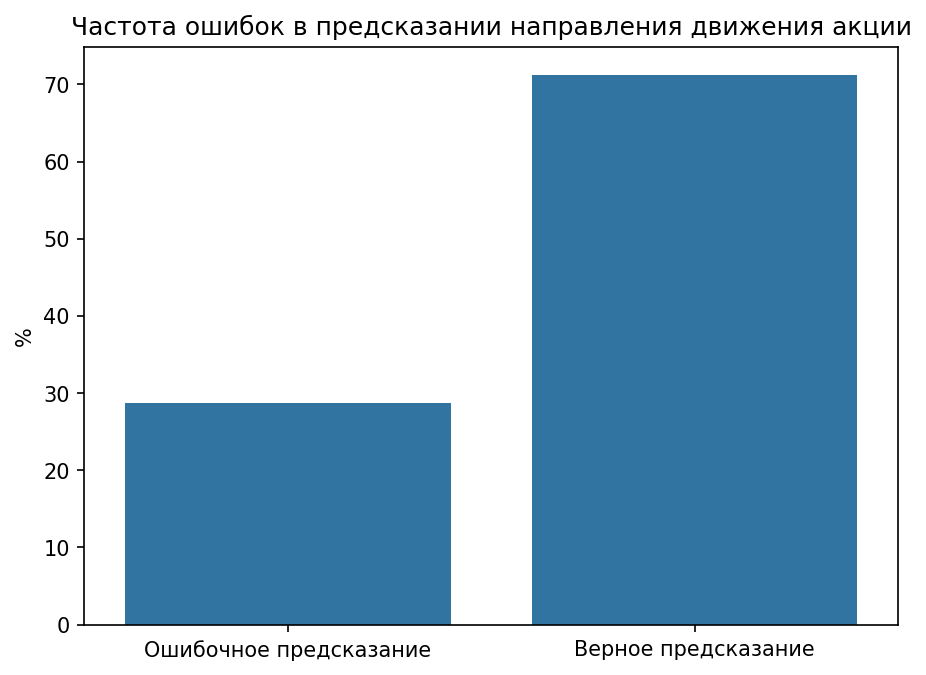

In [44]:
plt.figure(figsize=(7, 5), dpi =150)
sns.countplot(data = important, x = 'sign_match', stat='percent')
error = (len(important[important['sign_match'] == True]))/len(important)

plt.ylabel('%')
plt.xlabel('')
plt.title('Частота ошибок в предсказании направления движения акции')
plt.xticks([1, 0], ['Верное предсказание', 'Ошибочное предсказание'])
print (f'Модель ошиблась с направлением цены в {round(1-error, 3)*100}% случаев')

